# 🌸 Project 2 — Data Exploration: Iris Dataset
**Tasks covered:**
- Load the Iris dataset and explore its structure
- Check for missing values and handle them if necessary
- Visualize data distributions using various plots & graphs

---

## 1. Import Libraries

In [1]:

# Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Patch

# Dataset
from sklearn.datasets import load_iris

# Global style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'axes.titleweight' : 'bold',
})

PALETTE = ['#4CAF50', '#2196F3', '#FF5722']   # green / blue / orange

print('✅  All libraries imported successfully!')

✅  All libraries imported successfully!


---
## 2. Load the Iris Dataset

In [2]:
# Load via sklearn
iris_raw    = load_iris(as_frame=True)
df          = iris_raw.frame.copy()

# Rename columns for readability
df.columns  = ['sepal_length', 'sepal_width',
                'petal_length', 'petal_width', 'target']

# Map numeric target → species name
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species'] = df['target'].map(species_map)

FEATURES    = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
SPECIES     = list(species_map.values())

print(f'Dataset loaded  ✅')
print(f'Shape           : {df.shape}  (rows × columns)')
print(f'Features        : {FEATURES}')
print(f'Species         : {SPECIES}')

Dataset loaded  ✅
Shape           : (150, 6)  (rows × columns)
Features        : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Species         : ['setosa', 'versicolor', 'virginica']


---
## 3. Explore Dataset Structure

In [3]:
print('── First 5 rows ──────────────────────────────────────')
df.head()

── First 5 rows ──────────────────────────────────────


,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
print('── Last 5 rows ───────────────────────────────────────')
df.tail()

── Last 5 rows ───────────────────────────────────────


,sepal_length,sepal_width,petal_length,petal_width,target,species
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [5]:
print('── Dataset Info ──────────────────────────────────────')
df.info()

── Dataset Info ──────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   target        150 non-null    int64  
 5   species       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
print('── Data Types ────────────────────────────────────────')
print(df.dtypes)
print()
print('── Shape ─────────────────────────────────────────────')
print(f'Rows: {df.shape[0]} | Columns: {df.shape[1]}')

── Data Types ────────────────────────────────────────
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
target            int64
species          object
dtype: object

── Shape ─────────────────────────────────────────────
Rows: 150 | Columns: 6


In [7]:
print('── Statistical Summary ───────────────────────────────')
df[FEATURES].describe().T.style \
    .background_gradient(cmap='YlGn', axis=1) \
    .format(precision=3)

── Statistical Summary ───────────────────────────────


,count,mean,std,min,25%,50%,75%,max
sepal_length,150.000,5.843,0.828,4.300,5.100,5.800,6.400,7.900
sepal_width,150.000,3.057,0.436,2.000,2.800,3.000,3.300,4.400
petal_length,150.000,3.758,1.765,1.000,1.600,4.350,5.100,6.900
petal_width,150.000,1.199,0.762,0.100,0.300,1.300,1.800,2.500


In [8]:
print('── Per-Species Statistical Summary ──────────────────')
df.groupby('species')[FEATURES].describe().T

── Per-Species Statistical Summary ──────────────────


species                setosa  versicolor  virginica
sepal_length count  50.000000   50.000000  50.000000
             mean    5.006000    5.936000   6.588000
             std     0.352490    0.516171   0.635880
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.225000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
sepal_width  count  50.000000   50.000000  50.000000
             mean    3.428000    2.770000   2.974000
             std     0.379064    0.313798   0.322497
             min     2.300000    2.000000   2.200000
             25%     3.200000    2.525000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.675000    3.000000   3.175000
             max     4.400000    3.400000   3.800000
petal_length count  50.000000   50.000000  50.000000
             mean    1.462000    4.260000   5.552000
             std     0.173664    0.469911   0.551895
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.350000   5.550000
             75%     1.575000    4.600000   5.875000
             max     1.900000    5.100000   6.900000
petal_width  count  50.000000   50.000000  50.000000
             mean    0.246000    1.326000   2.026000
             std     0.105386    0.197753   0.274650
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000

---
## 4. Class Distribution

── Species Count ─────────────────────────────────────
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


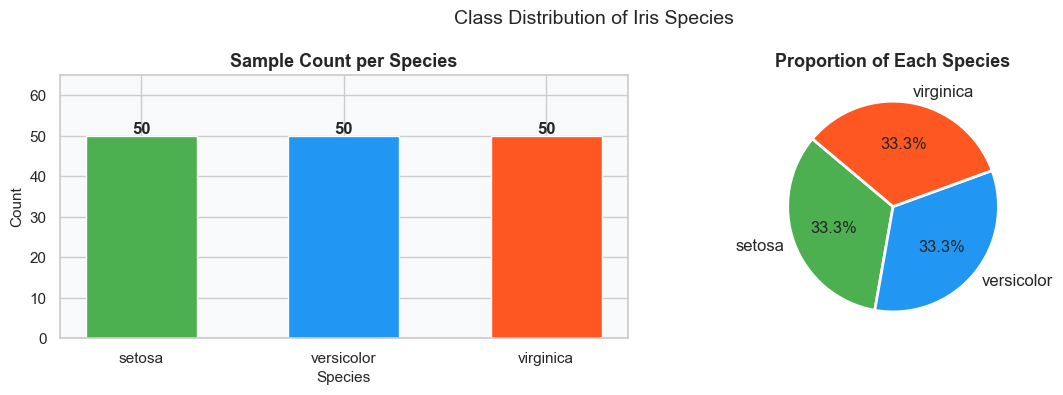

💾  Saved: class_distribution.png


In [9]:
print('── Species Count ─────────────────────────────────────')
print(df['species'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Class Distribution of Iris Species', fontsize=14)

# Bar chart
counts = df['species'].value_counts()
bars   = axes[0].bar(counts.index, counts.values,
                     color=PALETTE, edgecolor='white', width=0.55)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Sample Count per Species')
axes[0].set_xlabel('Species'); axes[0].set_ylabel('Count')
axes[0].set_ylim([0, 65])

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=PALETTE,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor':'white', 'linewidth':2},
            textprops={'fontsize':12})
axes[1].set_title('Proportion of Each Species')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: class_distribution.png')

## 5. Missing Value Analysis


In [10]:
print('── Missing Value Check ───────────────────────────────')
missing = df[FEATURES].isnull().sum()
pct     = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing (%)  ' : pct.round(2)
})
print(missing_df)
print()

if missing.sum() == 0:
    print('✅  No missing values found — dataset is complete!')
else:
    print(f'⚠️  {missing.sum()} missing value(s) detected — handling required.')

── Missing Value Check ───────────────────────────────
              Missing Count  Missing (%)  
sepal_length              0            0.0
sepal_width               0            0.0
petal_length              0            0.0
petal_width               0            0.0

✅  No missing values found — dataset is complete!


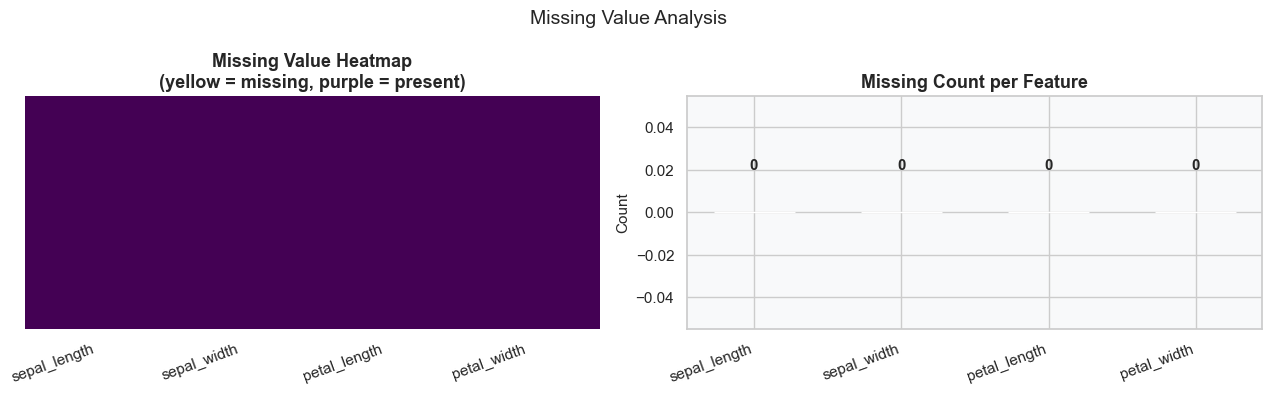

💾  Saved: missing_values.png


In [11]:
# ── Missing Value Heatmap ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Missing Value Analysis', fontsize=14)

# Heatmap
sns.heatmap(df[FEATURES].isnull(), cbar=False, cmap='viridis',
            yticklabels=False, ax=axes[0])
axes[0].set_title('Missing Value Heatmap\n(yellow = missing, purple = present)')
axes[0].set_xticklabels(FEATURES, rotation=20, ha='right')

# Bar chart
bar_colors = ['#f44336' if v > 0 else '#4CAF50' for v in missing.values]
axes[1].bar(FEATURES, missing.values, color=bar_colors, edgecolor='white', width=0.55)
axes[1].set_title('Missing Count per Feature')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(FEATURES, rotation=20, ha='right')
for i, v in enumerate(missing.values):
    axes[1].text(i, v + 0.02, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: missing_values.png')

In [12]:
# ── Missing Value Handling Strategy ─────────────────────────
# (Iris has no missing values, but this block handles any dataset)

if df[FEATURES].isnull().sum().sum() > 0:
    print('Handling missing values...')

    # Strategy 1: Drop rows with > 50% missing
    threshold = 0.5
    df = df[df[FEATURES].isnull().mean(axis=1) < threshold]

    # Strategy 2: Fill remaining with column median (robust to outliers)
    for col in FEATURES:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f'   Filled "{col}" missing values with median = {median_val:.3f}')

    print(f'\n✅  After handling — missing values: {df[FEATURES].isnull().sum().sum()}')
else:
    print('✅  No missing value handling needed — proceeding with clean dataset.')

✅  No missing value handling needed — proceeding with clean dataset.


---
## 6. Univariate Analysis — Distribution of Each Feature

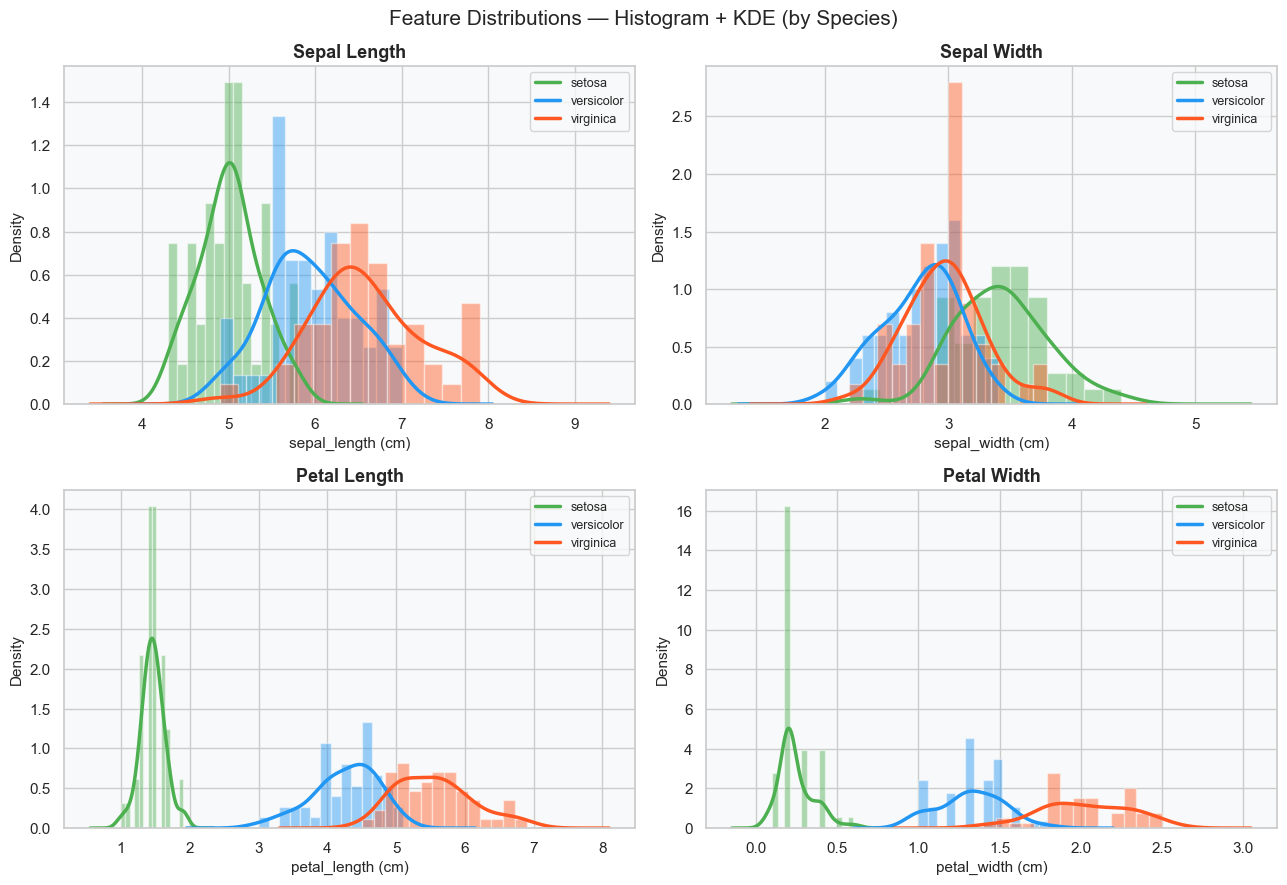

💾  Saved: histograms_kde.png


In [13]:
# ── Histograms with KDE for each feature ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Feature Distributions — Histogram + KDE (by Species)', fontsize=15)

for ax, feat in zip(axes.flat, FEATURES):
    for sp, color in zip(SPECIES, PALETTE):
        subset = df[df['species'] == sp][feat]
        ax.hist(subset, bins=14, alpha=0.45, color=color, edgecolor='white', density=True)
        subset.plot.kde(ax=ax, color=color, lw=2.5, label=sp)
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel(f'{feat} (cm)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('histograms_kde.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: histograms_kde.png')

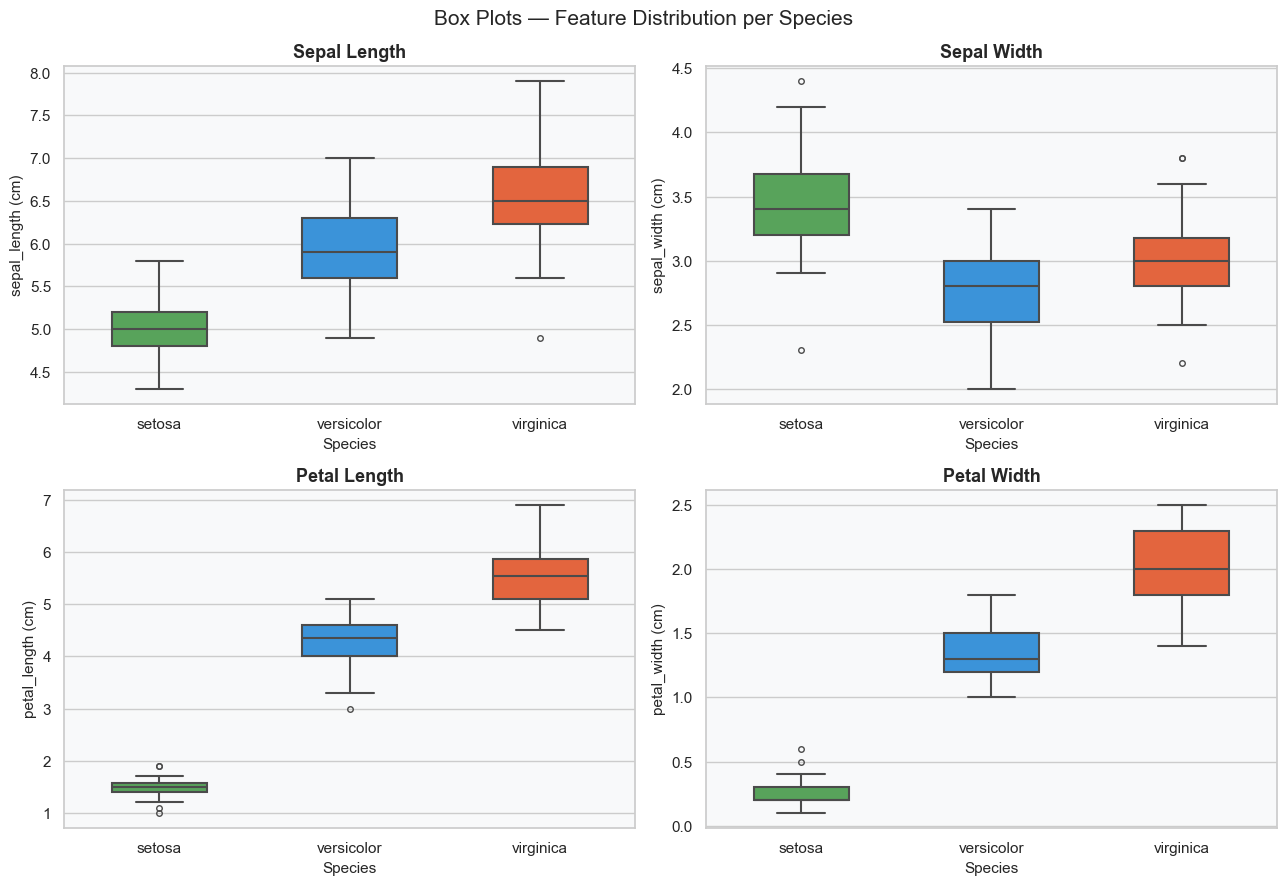

💾  Saved: boxplots.png


In [14]:
# ── Box Plots ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Box Plots — Feature Distribution per Species', fontsize=15)

for ax, feat in zip(axes.flat, FEATURES):
    sns.boxplot(data=df, x='species', y=feat, palette=PALETTE,
                width=0.5, linewidth=1.5, fliersize=4, ax=ax)
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('Species')
    ax.set_ylabel(f'{feat} (cm)')

plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: boxplots.png')

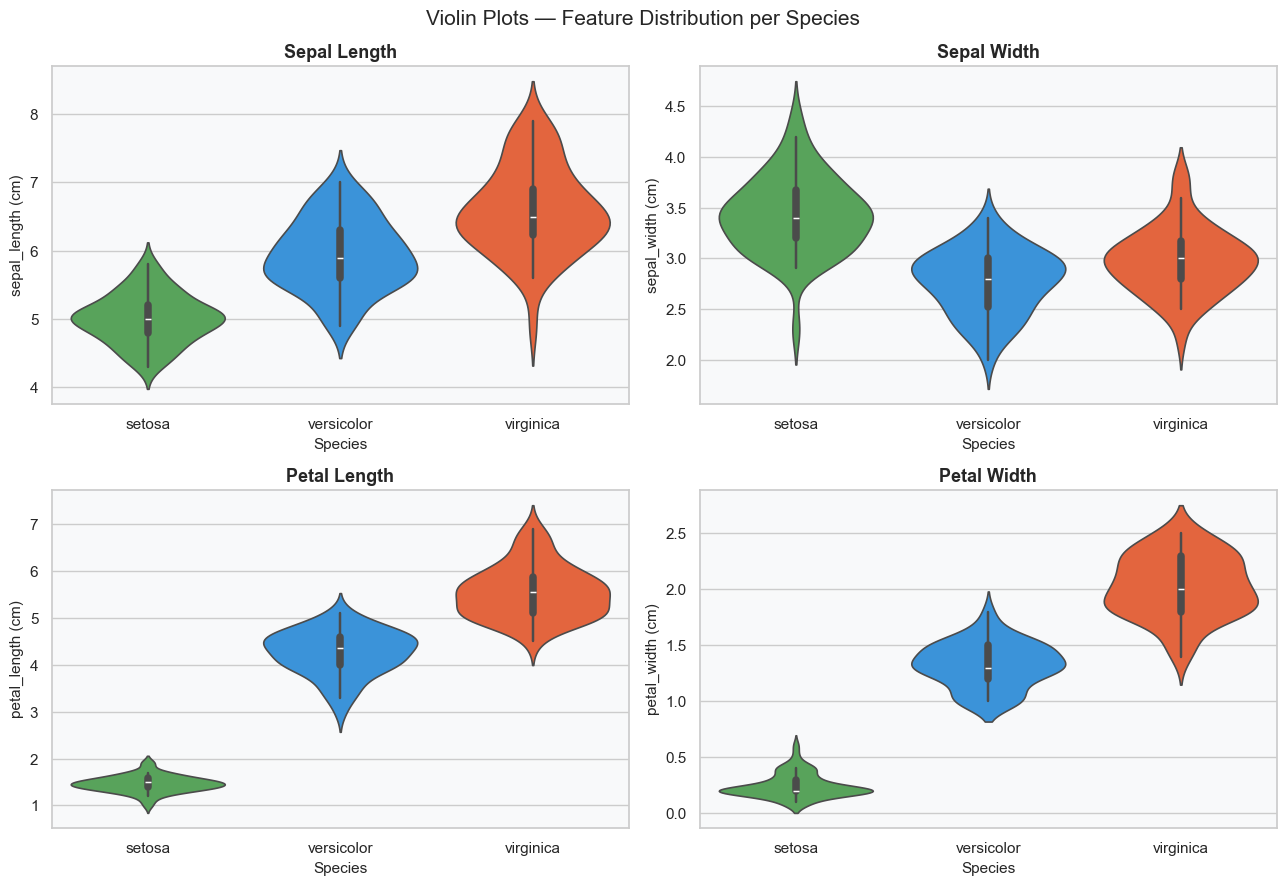

💾  Saved: violin_plots.png


In [15]:
# ── Violin Plots ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Violin Plots — Feature Distribution per Species', fontsize=15)

for ax, feat in zip(axes.flat, FEATURES):
    sns.violinplot(data=df, x='species', y=feat, palette=PALETTE,
                   inner='box', linewidth=1.2, ax=ax)
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('Species')
    ax.set_ylabel(f'{feat} (cm)')

plt.tight_layout()
plt.savefig('violin_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: violin_plots.png')

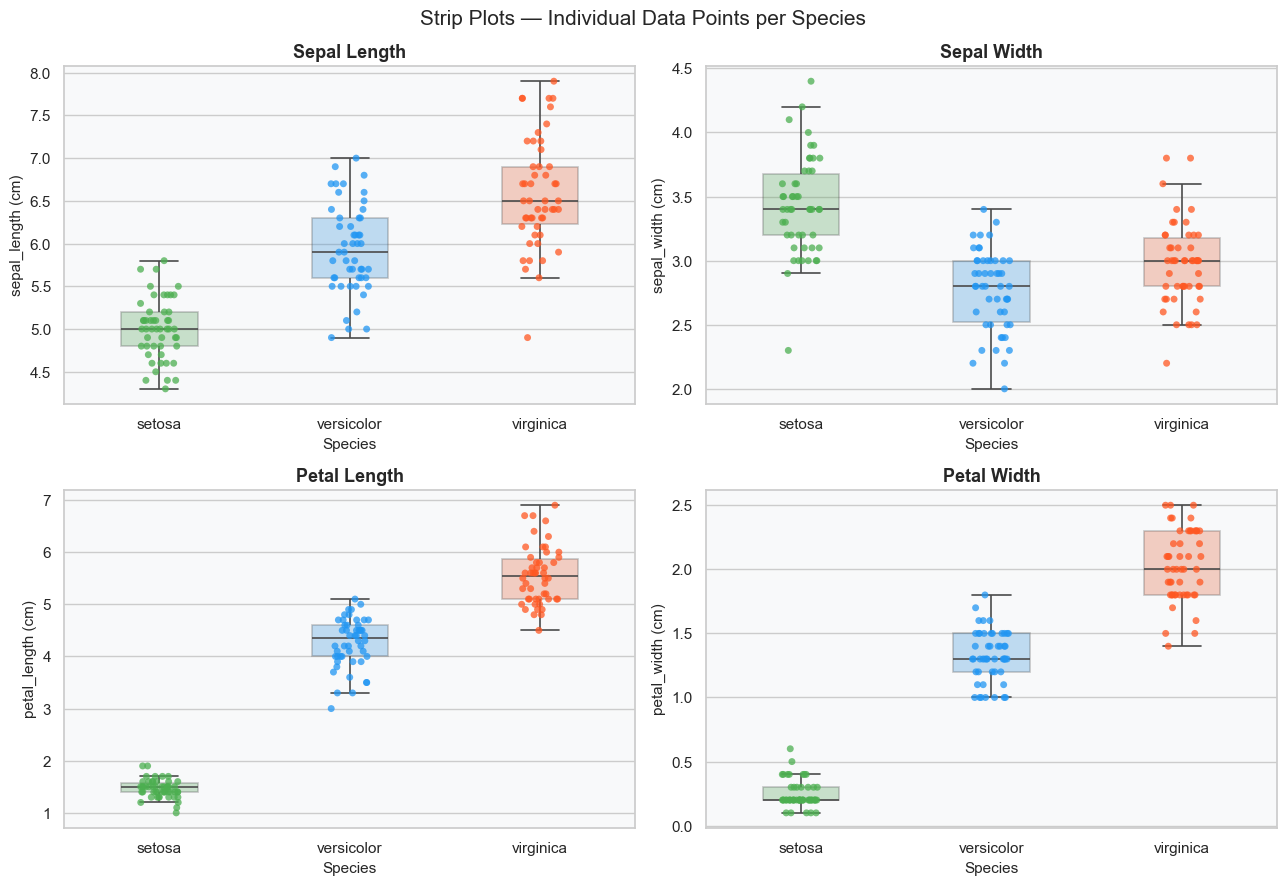

💾  Saved: strip_plots.png


In [16]:
# ── Strip / Swarm Plots ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Strip Plots — Individual Data Points per Species', fontsize=15)

for ax, feat in zip(axes.flat, FEATURES):
    sns.stripplot(data=df, x='species', y=feat, palette=PALETTE,
                  jitter=True, size=5, alpha=0.75, ax=ax)
    # Overlay box plot for reference
    sns.boxplot(data=df, x='species', y=feat, palette=PALETTE,
                width=0.4, linewidth=1.2, fliersize=0,
                boxprops=dict(alpha=0.3), ax=ax)
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('Species')
    ax.set_ylabel(f'{feat} (cm)')

plt.tight_layout()
plt.savefig('strip_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: strip_plots.png')

---
## 7. Bivariate Analysis — Feature Relationships

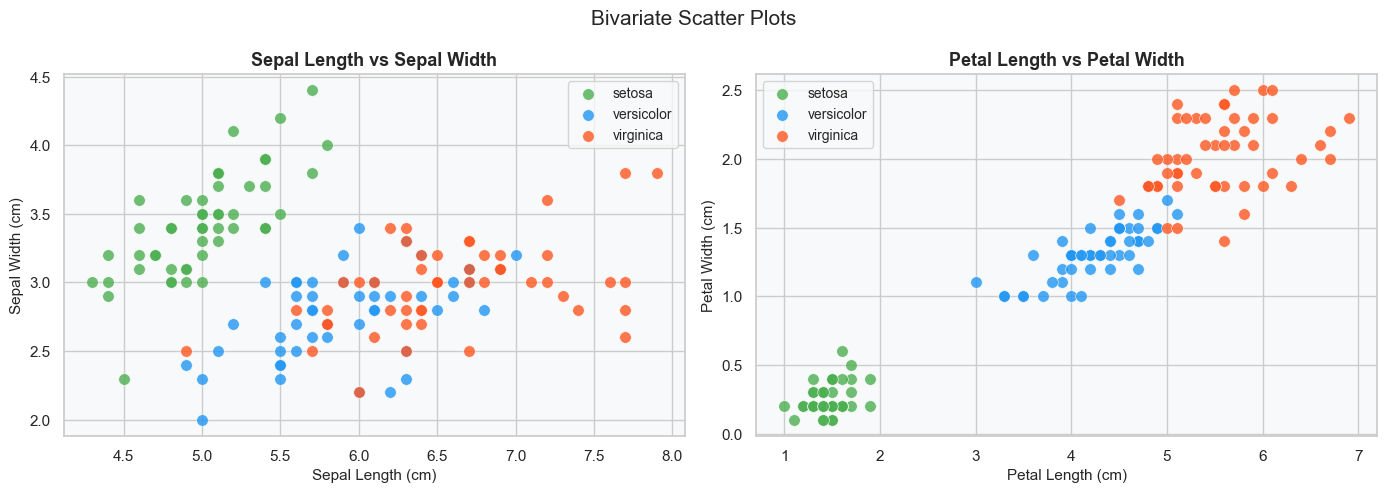

💾  Saved: scatter_plots.png


In [17]:
# ── Scatter Plots — Sepal vs Petal ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bivariate Scatter Plots', fontsize=15)

pairs = [
    ('sepal_length', 'sepal_width',  'Sepal Length vs Sepal Width'),
    ('petal_length', 'petal_width',  'Petal Length vs Petal Width'),
]

for ax, (x, y, title) in zip(axes, pairs):
    for sp, color in zip(SPECIES, PALETTE):
        subset = df[df['species'] == sp]
        ax.scatter(subset[x], subset[y], color=color, label=sp,
                   s=70, alpha=0.8, edgecolors='white', linewidths=0.5)
    ax.set_xlabel(x.replace('_',' ').title() + ' (cm)')
    ax.set_ylabel(y.replace('_',' ').title() + ' (cm)')
    ax.set_title(title)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: scatter_plots.png')

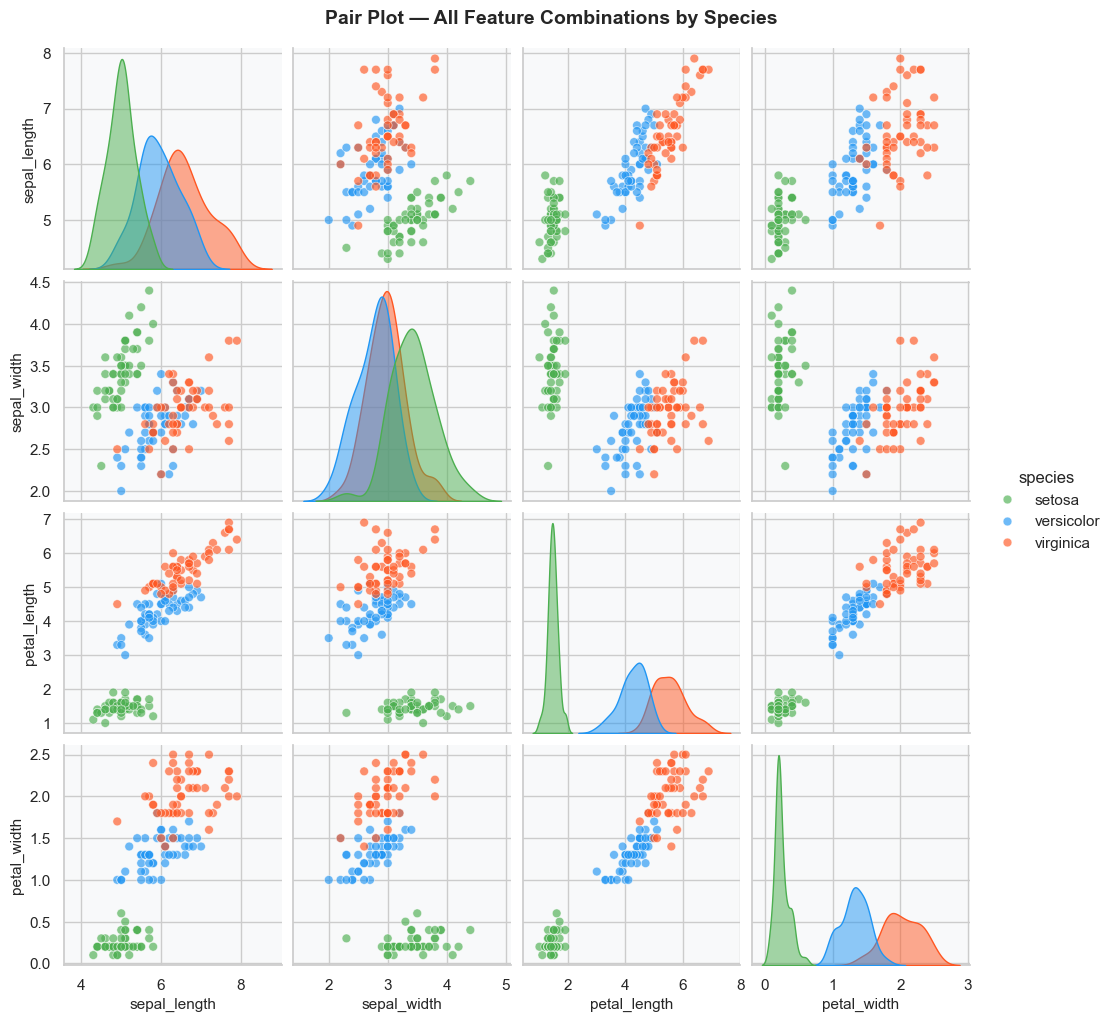

💾  Saved: pair_plot.png


In [18]:
# ── Pair Plot — All Feature Combinations ────────────────────
pair_grid = sns.pairplot(
    df[FEATURES + ['species']],
    hue='species',
    palette=dict(zip(SPECIES, PALETTE)),
    diag_kind='kde',
    plot_kws={'alpha': 0.65, 's': 40, 'edgecolor': 'white'},
    diag_kws={'fill': True, 'alpha': 0.5},
    height=2.5
)
pair_grid.figure.suptitle('Pair Plot — All Feature Combinations by Species',
                            y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pair_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: pair_plot.png')

---
## 8. Correlation Analysis

In [19]:
corr_matrix = df[FEATURES].corr()

print('── Correlation Matrix ────────────────────────────────')
corr_matrix.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3)

── Correlation Matrix ────────────────────────────────


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


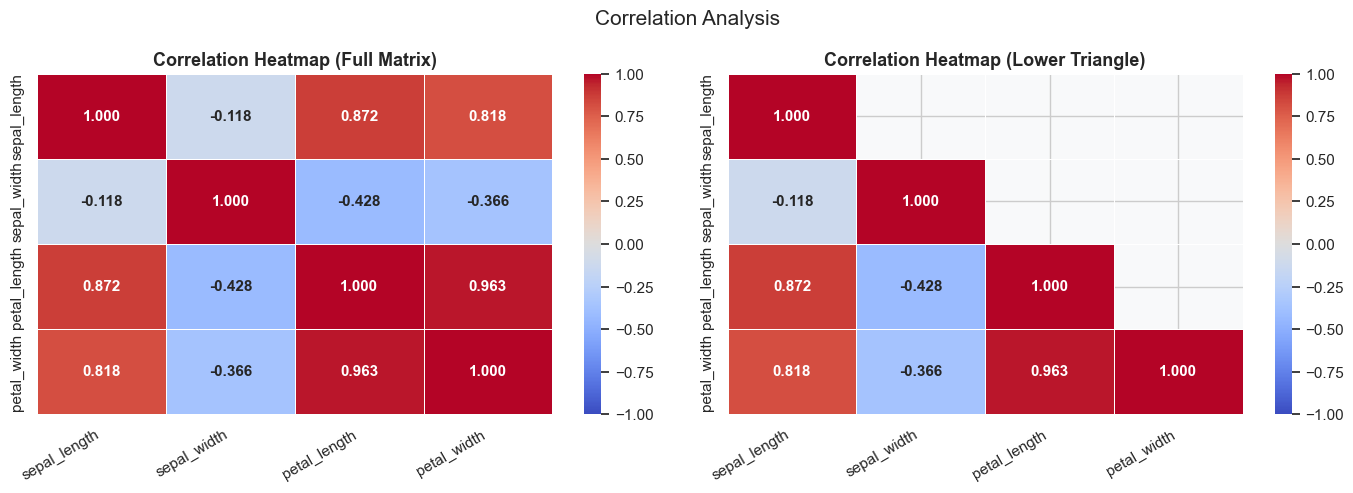

💾  Saved: correlation_heatmap.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Correlation Analysis', fontsize=15)

# Full heatmap
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True   # upper triangle only

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=axes[0],
            annot_kws={'size': 11, 'weight': 'bold'})
axes[0].set_title('Correlation Heatmap (Full Matrix)')
axes[0].set_xticklabels(FEATURES, rotation=30, ha='right')

# Lower triangle only
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5, ax=axes[1],
            annot_kws={'size': 11, 'weight': 'bold'})
axes[1].set_title('Correlation Heatmap (Lower Triangle)')
axes[1].set_xticklabels(FEATURES, rotation=30, ha='right')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: correlation_heatmap.png')

---
## 9. Outlier Detection

In [21]:
# ── IQR-based Outlier Detection ──────────────────────────────
print('── Outlier Summary (IQR Method) ──────────────────────')
outlier_summary = []

for feat in FEATURES:
    Q1  = df[feat].quantile(0.25)
    Q3  = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    low  = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    n_out = ((df[feat] < low) | (df[feat] > high)).sum()
    outlier_summary.append({
        'Feature'   : feat,
        'Q1'        : round(Q1,  3),
        'Q3'        : round(Q3,  3),
        'IQR'       : round(IQR, 3),
        'Lower Fence': round(low,  3),
        'Upper Fence': round(high, 3),
        'Outliers'  : n_out,
    })

outlier_df = pd.DataFrame(outlier_summary).set_index('Feature')
outlier_df.style.highlight_max(subset=['Outliers'], color='#ffcccc')

── Outlier Summary (IQR Method) ──────────────────────


,Q1,Q3,IQR,Lower Fence,Upper Fence,Outliers
Feature,,,,,,
sepal_length,5.100000,6.400000,1.300000,3.150000,8.350000,0
sepal_width,2.800000,3.300000,0.500000,2.050000,4.050000,4
petal_length,1.600000,5.100000,3.500000,-3.650000,10.350000,0
petal_width,0.300000,1.800000,1.500000,-1.950000,4.050000,0


In [24]:
# ── Z-Score Outlier Detection ────────────────────────────────
from scipy import stats

print('── Z-Score Outlier Count (|z| > 3) ──────────────────')
z_scores   = np.abs(stats.zscore(df[FEATURES]))
z_outliers = (z_scores > 3).sum(axis=0)
print(pd.Series(z_outliers, index=FEATURES, name='Outliers (|z|>3)'))

── Z-Score Outlier Count (|z| > 3) ──────────────────
sepal_length    0
sepal_width     1
petal_length    0
petal_width     0
Name: Outliers (|z|>3), dtype: int64


---
## 10. Feature Statistics — Deeper Look

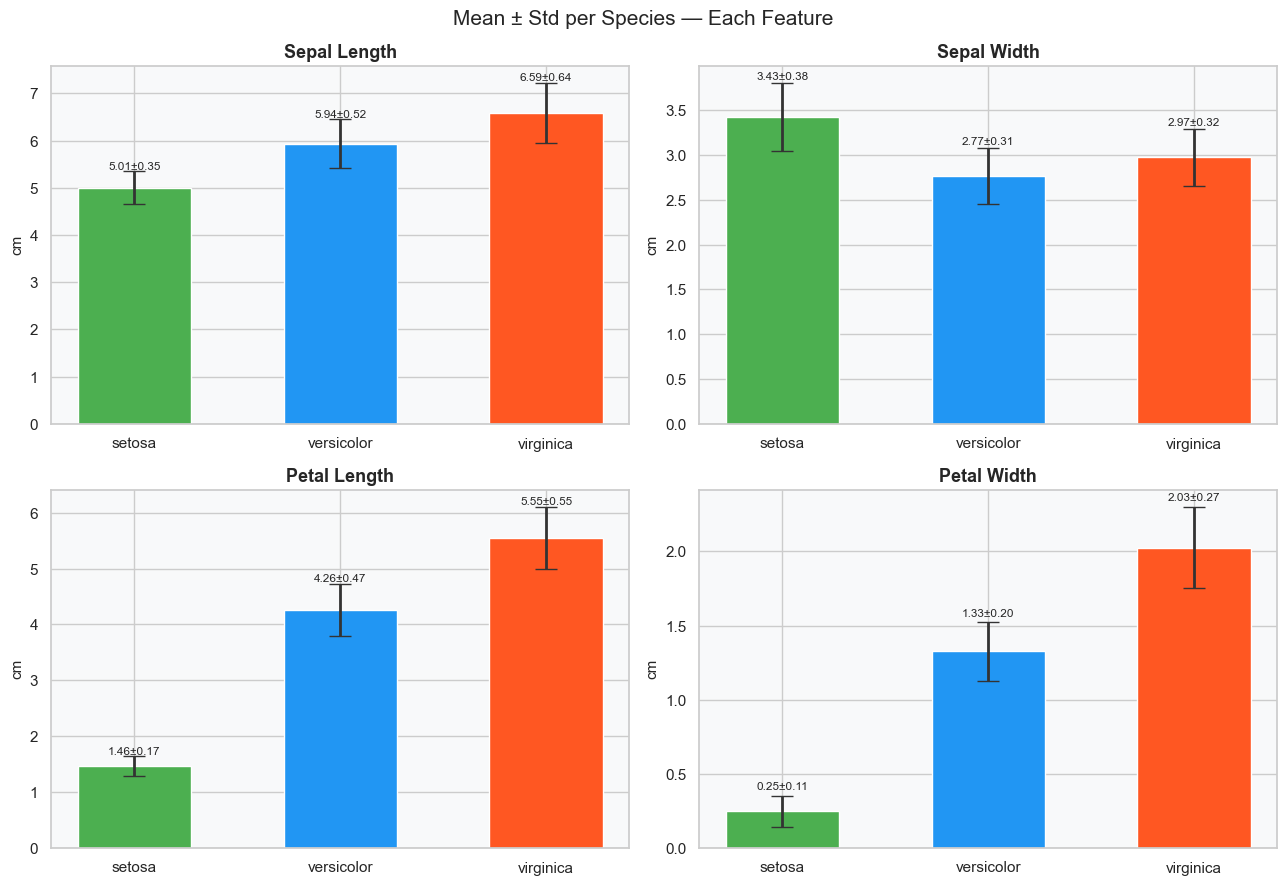

💾  Saved: mean_std_bars.png


In [25]:
# ── Mean ± Std per species per feature ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Mean ± Std per Species — Each Feature', fontsize=15)

for ax, feat in zip(axes.flat, FEATURES):
    group = df.groupby('species')[feat]
    means = group.mean()
    stds  = group.std()
    x_pos = np.arange(len(SPECIES))

    bars = ax.bar(x_pos, means, yerr=stds, color=PALETTE,
                  capsize=8, edgecolor='white', width=0.55,
                  error_kw={'linewidth': 2, 'ecolor': '#333'})
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + s + 0.04,
                f'{m:.2f}±{s:.2f}', ha='center', fontsize=8.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(SPECIES)
    ax.set_title(feat.replace('_',' ').title())
    ax.set_ylabel('cm')

plt.tight_layout()
plt.savefig('mean_std_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: mean_std_bars.png')

── Skewness & Kurtosis ───────────────────────────────
              Skewness  Kurtosis
sepal_length    0.3149   -0.5521
sepal_width     0.3190    0.2282
petal_length   -0.2749   -1.4021
petal_width    -0.1030   -1.3406


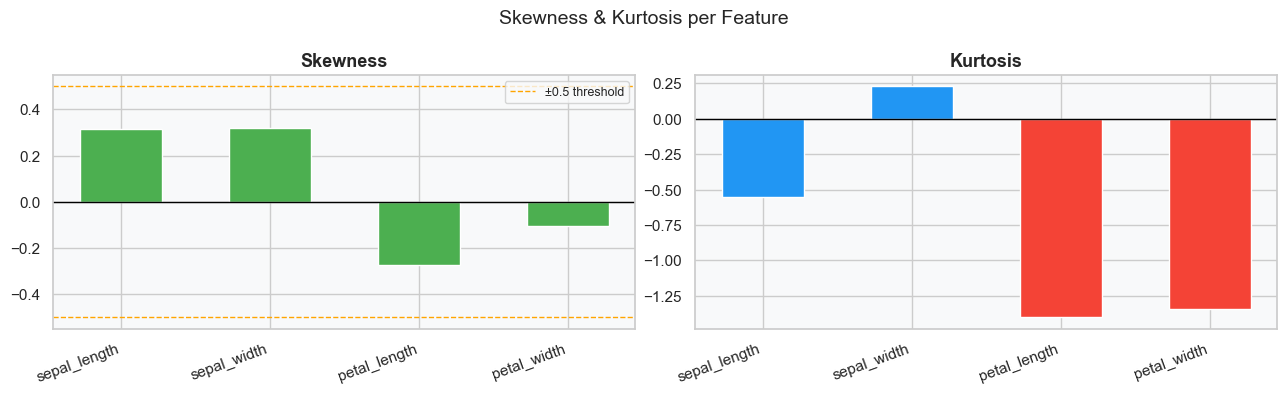

💾  Saved: skewness_kurtosis.png


In [26]:
# ── Skewness & Kurtosis ──────────────────────────────────────
print('── Skewness & Kurtosis ───────────────────────────────')
sk_df = pd.DataFrame({
    'Skewness' : df[FEATURES].skew().round(4),
    'Kurtosis' : df[FEATURES].kurt().round(4)
})
print(sk_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Skewness & Kurtosis per Feature', fontsize=14)

sk_colors = ['#f44336' if abs(v) > 0.5 else '#4CAF50' for v in sk_df['Skewness']]
axes[0].bar(FEATURES, sk_df['Skewness'], color=sk_colors, edgecolor='white', width=0.55)
axes[0].axhline(0, color='black', lw=1)
axes[0].axhline( 0.5, color='orange', lw=1, linestyle='--', label='±0.5 threshold')
axes[0].axhline(-0.5, color='orange', lw=1, linestyle='--')
axes[0].set_title('Skewness')
axes[0].set_xticklabels(FEATURES, rotation=20, ha='right')
axes[0].legend(fontsize=9)

kurt_colors = ['#f44336' if abs(v) > 1 else '#2196F3' for v in sk_df['Kurtosis']]
axes[1].bar(FEATURES, sk_df['Kurtosis'], color=kurt_colors, edgecolor='white', width=0.55)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Kurtosis')
axes[1].set_xticklabels(FEATURES, rotation=20, ha='right')

plt.tight_layout()
plt.savefig('skewness_kurtosis.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: skewness_kurtosis.png')

---
## 11. 3D Scatter Plot

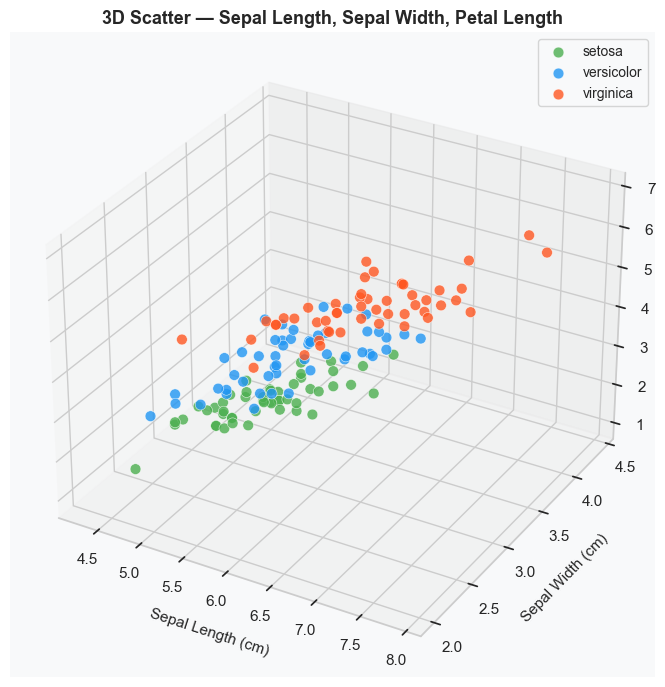

💾  Saved: 3d_scatter.png


In [27]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

for sp, color in zip(SPECIES, PALETTE):
    subset = df[df['species'] == sp]
    ax.scatter(subset['sepal_length'], subset['sepal_width'],
               subset['petal_length'],
               c=color, label=sp, s=60, alpha=0.8,
               edgecolors='white', linewidths=0.4)

ax.set_xlabel('Sepal Length (cm)', labelpad=8)
ax.set_ylabel('Sepal Width (cm)',  labelpad=8)
ax.set_zlabel('Petal Length (cm)', labelpad=8)
ax.set_title('3D Scatter — Sepal Length, Sepal Width, Petal Length',
             fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('3d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: 3d_scatter.png')

---
## 12. Cumulative Distribution Functions (CDF)

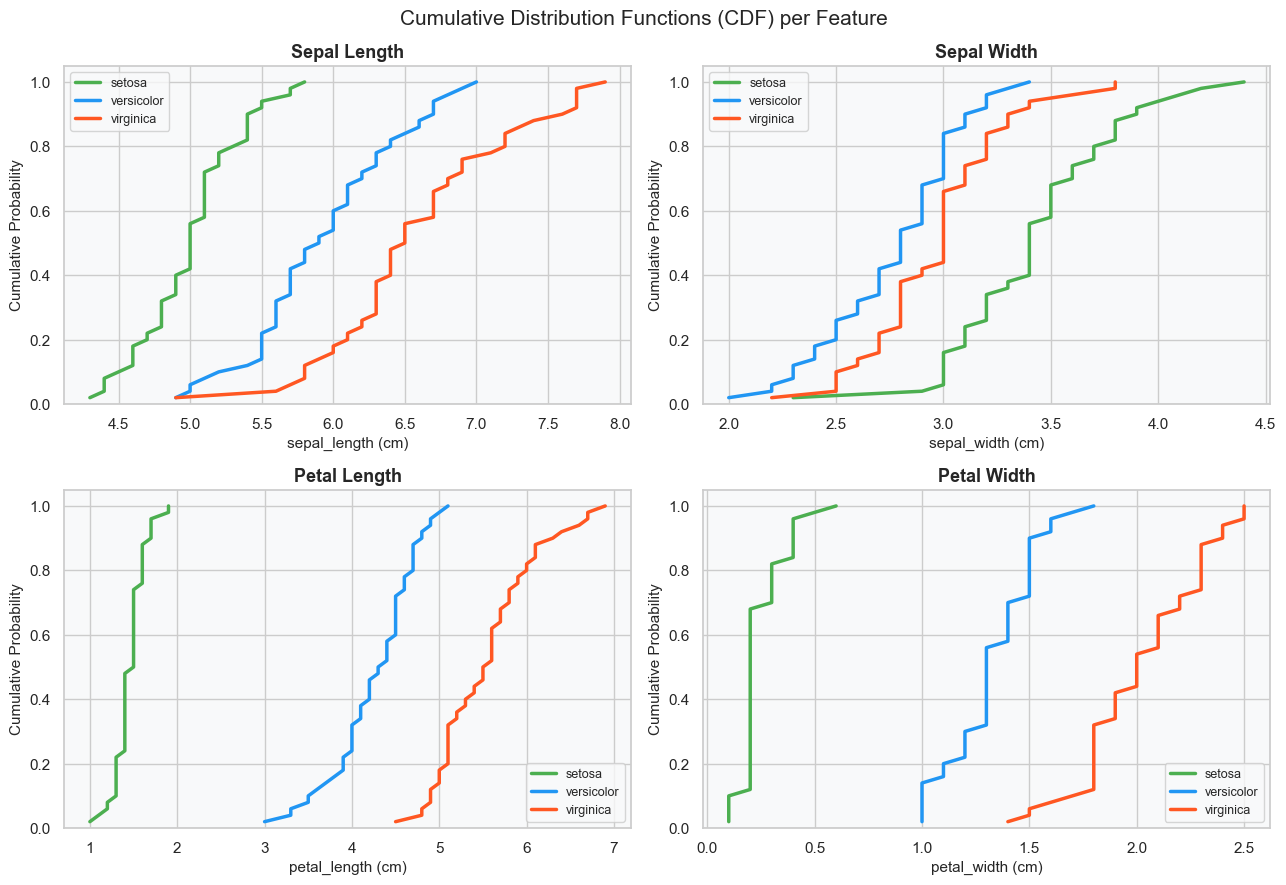

💾  Saved: cdf_plots.png


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Cumulative Distribution Functions (CDF) per Feature', fontsize=15)

for ax, feat in zip(axes.flat, FEATURES):
    for sp, color in zip(SPECIES, PALETTE):
        subset  = df[df['species'] == sp][feat].sort_values()
        cdf_y   = np.arange(1, len(subset)+1) / len(subset)
        ax.plot(subset, cdf_y, lw=2.5, color=color, label=sp)
    ax.set_title(feat.replace('_',' ').title())
    ax.set_xlabel(f'{feat} (cm)')
    ax.set_ylabel('Cumulative Probability')
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('cdf_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: cdf_plots.png')

---
## 13. Final Summary Dashboard

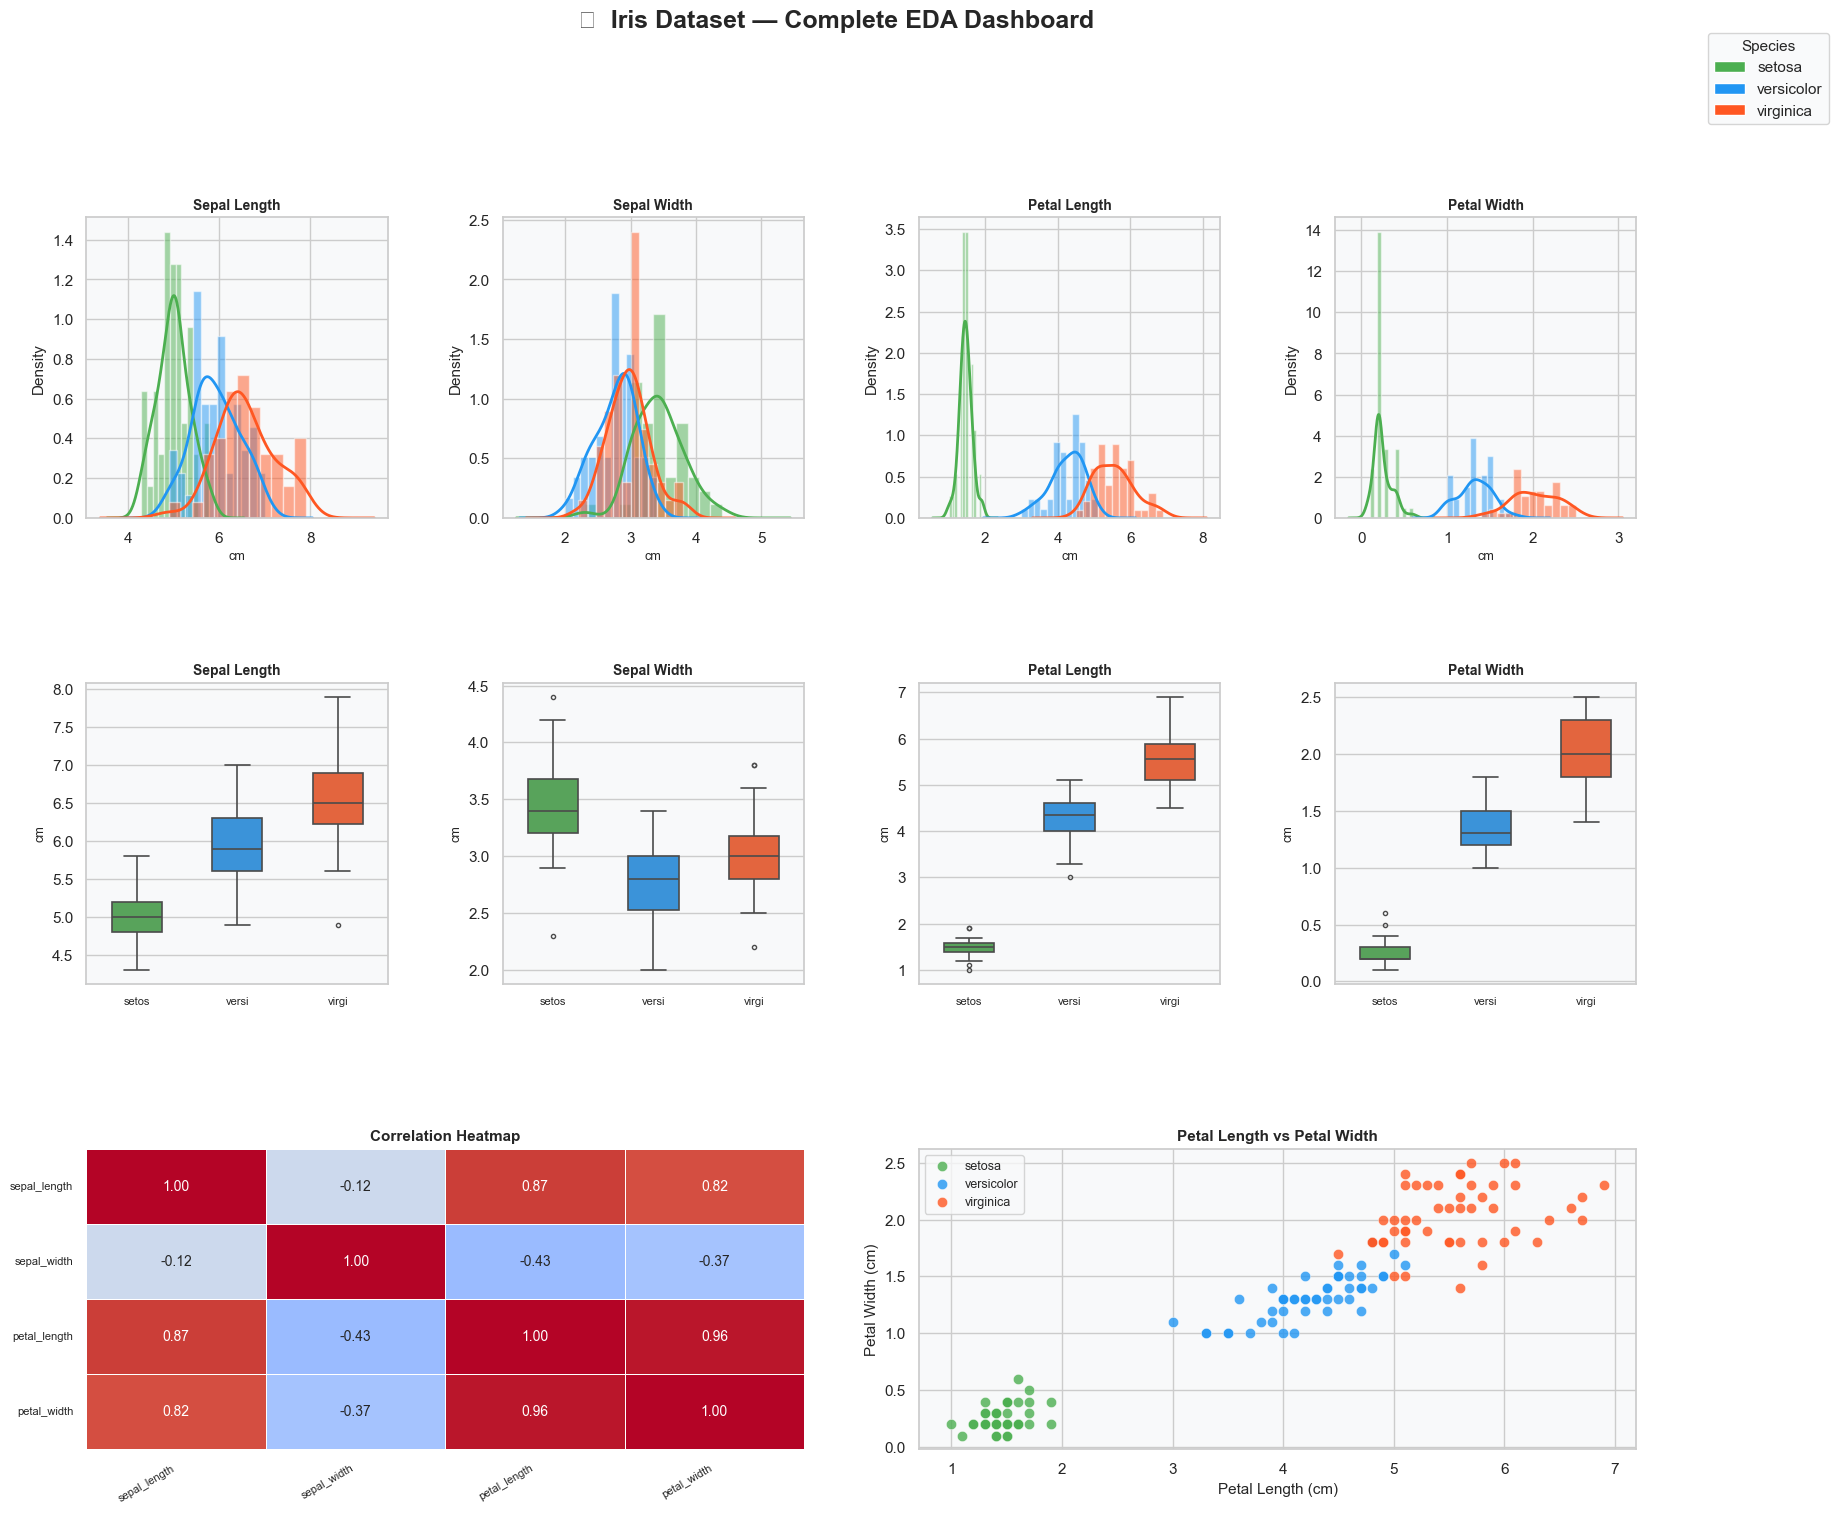

💾  Saved: eda_dashboard.png


In [29]:
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.38)
fig.suptitle('🌸  Iris Dataset — Complete EDA Dashboard', fontsize=18, fontweight='bold', y=1.01)

# ── Row 1 : Histograms ───────────────────────────────────────
for col, feat in enumerate(FEATURES):
    ax = fig.add_subplot(gs[0, col])
    for sp, color in zip(SPECIES, PALETTE):
        subset = df[df['species'] == sp][feat]
        ax.hist(subset, bins=12, alpha=0.5, color=color, density=True, edgecolor='white')
        subset.plot.kde(ax=ax, color=color, lw=2)
    ax.set_title(feat.replace('_',' ').title(), fontsize=10)
    ax.set_xlabel('cm', fontsize=9)

# ── Row 2 : Box plots ────────────────────────────────────────
for col, feat in enumerate(FEATURES):
    ax = fig.add_subplot(gs[1, col])
    sns.boxplot(data=df, x='species', y=feat, palette=PALETTE,
                width=0.5, linewidth=1.2, fliersize=3, ax=ax)
    ax.set_title(feat.replace('_',' ').title(), fontsize=10)
    ax.set_xlabel('')
    ax.set_xticklabels([s[:5] for s in SPECIES], fontsize=8)
    ax.set_ylabel('cm', fontsize=9)

# ── Row 3 : Correlation heatmap + Pair scatter ───────────────
ax_corr = fig.add_subplot(gs[2, :2])
sns.heatmap(df[FEATURES].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax_corr, cbar=False,
            annot_kws={'size': 10})
ax_corr.set_title('Correlation Heatmap', fontsize=11)
ax_corr.set_xticklabels(FEATURES, rotation=30, ha='right', fontsize=8)
ax_corr.set_yticklabels(FEATURES, rotation=0, fontsize=8)

ax_sc = fig.add_subplot(gs[2, 2:])
for sp, color in zip(SPECIES, PALETTE):
    sub = df[df['species'] == sp]
    ax_sc.scatter(sub['petal_length'], sub['petal_width'],
                  color=color, label=sp, s=55, alpha=0.8,
                  edgecolors='white', linewidths=0.4)
ax_sc.set_xlabel('Petal Length (cm)'); ax_sc.set_ylabel('Petal Width (cm)')
ax_sc.set_title('Petal Length vs Petal Width', fontsize=11)
ax_sc.legend(fontsize=9)

# Common legend for rows 1 & 2
legend_elements = [Patch(facecolor=c, label=s) for c, s in zip(PALETTE, SPECIES)]
fig.legend(handles=legend_elements, loc='upper right',
           fontsize=11, title='Species', title_fontsize=11,
           bbox_to_anchor=(1.0, 1.0))

plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: eda_dashboard.png')

---
## 14. Key Findings & Summary

In [30]:
print('=' * 65)
print('        📋  IRIS DATASET — EDA SUMMARY')
print('=' * 65)
print(f'Total samples         : {len(df)}')
print(f'Features              : {len(FEATURES)}')
print(f'Classes               : {len(SPECIES)}  →  {SPECIES}')
print(f'Missing values        : {df[FEATURES].isnull().sum().sum()}')
print(f'Balanced dataset      : {df["species"].value_counts().nunique() == 1}')
print()
print('── Feature Ranges ────────────────────────────────────')
for feat in FEATURES:
    print(f'  {feat:18s}: {df[feat].min():.1f} – {df[feat].max():.1f} cm  '
          f'(mean={df[feat].mean():.2f}, std={df[feat].std():.2f})')
print()
print('── Key Observations ──────────────────────────────────')
print('  • Setosa is clearly separable from the other two species')
print('  • Petal features have stronger discriminating power')
print('  • Petal length & petal width are highly correlated (r ≈ 0.96)')
print('  • Versicolor & Virginica overlap more in feature space')
print('  • No missing values — dataset is clean and ready for modeling')
print()
print('📂  Saved Plots:')
for f in ['class_distribution.png','missing_values.png','histograms_kde.png',
          'boxplots.png','violin_plots.png','strip_plots.png',
          'scatter_plots.png','pair_plot.png','correlation_heatmap.png',
          'mean_std_bars.png','skewness_kurtosis.png',
          '3d_scatter.png','cdf_plots.png','eda_dashboard.png']:
    print(f'  • {f}')
print('=' * 65)

        📋  IRIS DATASET — EDA SUMMARY
Total samples         : 150
Features              : 4
Classes               : 3  →  ['setosa', 'versicolor', 'virginica']
Missing values        : 0
Balanced dataset      : True

── Feature Ranges ────────────────────────────────────
  sepal_length      : 4.3 – 7.9 cm  (mean=5.84, std=0.83)
  sepal_width       : 2.0 – 4.4 cm  (mean=3.06, std=0.44)
  petal_length      : 1.0 – 6.9 cm  (mean=3.76, std=1.77)
  petal_width       : 0.1 – 2.5 cm  (mean=1.20, std=0.76)

── Key Observations ──────────────────────────────────
  • Setosa is clearly separable from the other two species
  • Petal features have stronger discriminating power
  • Petal length & petal width are highly correlated (r ≈ 0.96)
  • Versicolor & Virginica overlap more in feature space
  • No missing values — dataset is clean and ready for modeling

📂  Saved Plots:
  • class_distribution.png
  • missing_values.png
  • histograms_kde.png
  • boxplots.png
  • violin_plots.png
  • strip_plots

---
### 📝 Plot Reference Guide
| Plot | Purpose |
|------|---------|
| **Histogram + KDE** | Shape of distribution per species |
| **Box Plot** | Median, IQR, and outliers per feature |
| **Violin Plot** | Distribution density + box stats combined |
| **Strip Plot** | Every individual data point |
| **Pair Plot** | All pairwise feature relationships |
| **Correlation Heatmap** | Linear relationships between features |
| **3D Scatter** | Three features visualized simultaneously |
| **CDF Plot** | Cumulative probability across feature range |
| **Mean ± Std Bar** | Central tendency + spread per species |
| **EDA Dashboard** | One-page visual summary of entire dataset |